In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from hampel import hampel

In [4]:
import os

print(os.getcwd())
print(os.listdir("."))

C:\Users\HydroResearch\Documents\GitHub\summer_26\summer 2026
['.ipynb_checkpoints', '.~BridgeLevellogger.6.23.26.csv', '.~NOAAHastingsDam2Since2024.csv', '.~P1_All_6.16.csv', '.~Well_Sampling_Data_P1.csv', 'AllPTemps.ipynb', 'bell2026.yml', 'BridgeLevellogger.6.23.26.csv', 'CreeksBell2026.ipynb', 'filteredhobo1.xlsx', 'GenericBell2026-Copy1.ipynb', 'LeveloggerFiles.ipynb', 'Manual_Data_P1.csv', 'NOAAHastingsDam2.csv', 'NOAAHastingsDam2Since2024.csv', 'P1Bell2026.ipynb', 'P1Levellogger.6.23.26.csv', 'P1ManualData.csv', 'P1SPCBell2026.ipynb', 'P1_All_6.16.csv', 'P1_creek_current.csv', 'P1_current.csv', 'P1_Day_June15Only.csv', 'P1_Month_MayOnly.csv', 'P1_SPC_Calibration.csv', 'P2Bell2026.ipynb', 'P2ManualData.csv', 'P2SPCBell2026.ipynb', 'P2_creek_current.csv', 'P2_current.csv', 'P3Bell2026-Copy1.ipynb', 'P3ManualData.csv', 'P3_current.csv', 'P4Bell2026.ipynb', 'P4ManualData.csv', 'P4_creek_current.csv', 'P4_current.csv', 'P5Bell2026.ipynb', 'P5Levellogger.6.23.26.csv', 'P5ManualData.cs

In [32]:
hobodf = pd.read_csv("P3_current.csv")
hobodf = hobodf.dropna()
hobodf.columns = hobodf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe. 
hobodf["Date-Time"] = pd.to_datetime(hobodf["Date-Time"])
hobodate = hobodf["Date-Time"]
slicedhobodate = hobodate[1:]
hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
0,2025-01-29 17:17:59,1.485813,4.840961,9.563297,0.002535,3.146625
1,2025-01-29 17:32:59,4.471104,409.075958,719.073364,0.325645,265.899353
2,2025-01-29 17:47:59,4.568516,410.281891,718.609192,0.325706,266.683228
3,2025-01-29 18:02:59,4.600956,410.486023,718.109863,0.325563,266.815918
4,2025-01-29 18:17:59,4.623661,410.468811,717.481262,0.325331,266.804718
...,...,...,...,...,...,...
48948,2026-06-23 15:17:59,12.432133,594.497131,807.658569,0.385494,386.423126
48949,2026-06-23 15:32:59,12.432133,594.616333,807.820557,0.385574,386.500610
48950,2026-06-23 15:47:59,12.432133,594.437500,807.577576,0.385454,386.384369
48951,2026-06-23 16:02:59,12.432133,594.615540,807.819458,0.385574,386.500092


In [33]:
mandf = pd.read_csv("P3ManualData.csv")
mandf = mandf.drop(np.arange(0, 29))
mandf

,Well,Date,Depth to water,Temp top before,Temp bottom before,SPC top before,SPC bottom before,Cond top before,Cond bottom before,TDS top before,...,Recharge time,Temp top after,Temp bottom after,SPC top after,SPC bottom after,Cond top after,Cond bottom after,TDS top after,TDS bottom after,Notes
29,P3,10/7/2025 0:00:00,5.37,16.0,14.2,788.0,790.0,656.0,628.0,0.4,...,3.51.04,15.1,12.7,637.0,603.0,782.0,786.0,0.4,0.4,NaN
30,P3,10/14/2025 0:00:00,5.41,13.8,13.3,780.0,799.0,612.0,621.0,0.4,...,4:06.04,13.4,13.2,608.0,606.0,782.0,783.0,0.4,0.4,NaN
31,P3,10/28/2025 0:00:00,5.39,11.6,11.8,797.0,801.0,594.0,600.0,0.4,...,04:51.00,11.6,11.7,589.0,594.0,786.0,796.0,0.4,0.4,NaN
32,P3,11/4/2025 0:00:00,5.42,10.8,11.0,821.0,815.0,601.0,596.0,0.4,...,3:13.36,11.0,11.0,586.0,588.0,800.0,804.0,0.4,0.4,NaN
33,P3,11/11/2025 0:00:00,5.47,9.8,10.3,817.0,811.0,580.0,585.0,0.4,...,5:00.00,10.0,10.4,796.0,803.0,568.0,578.0,0.4,0.4,NaN
34,P3,11/18/2025 0:00:00,5.40,8.7,9.8,813.0,812.0,560.0,576.0,0.4,...,03:22.44,9.0,9.7,791.0,805.0,549.0,570.0,0.4,0.4,NaN
35,P3,1/6/2026 0:00:00,5.53,4.3,6.8,794.0,795.0,481.0,519.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,P3,1/13/2026 0:00:00,5.56,4.6,6.8,789.0,790.0,482.0,515.0,0.4,...,2:49.71,5.3,6.7,777.0,784.0,484.0,511.0,0.4,0.4,NaN
37,P3,2/3/2026 0:00:00,5.61,3.7,6.2,783.0,778.0,465.0,500.0,0.4,...,3:58.52,4.6,6.2,770.0,772.0,469.0,495.0,0.4,0.4,NaN
38,P3,2/17/2026 0:00:00,5.64,3.1,6.0,777.0,779.0,453.6,496.0,0.4,...,2:48.22,4.6,5.8,775.0,773.0,474.0,492.0,0.4,0.4,NaN


In [34]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
filteredhobo = hampel(hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)
filteredhoboseries = pd.Series(filteredhobo.filtered_data, index = hobodf.index)
filteredhobo = filteredhoboseries[1:]

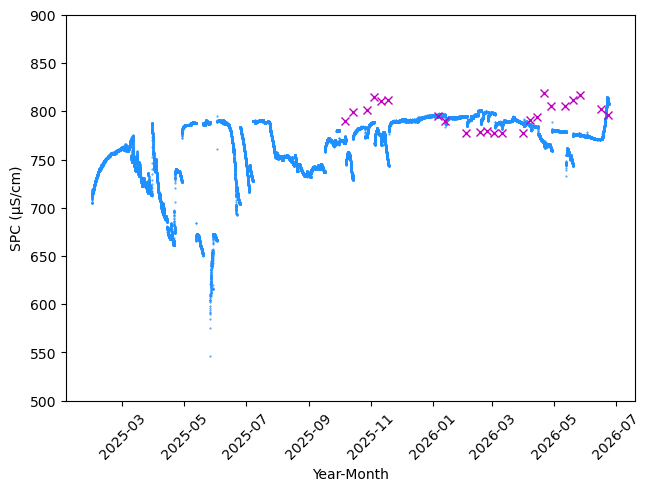

In [36]:
# hobodf.columns = hobodf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  
# hobodf = pd.read_csv("P1_All_6.16.csv")
# mandf = pd.read_csv("P2ManualData.csv")
mandf["Date"] = pd.to_datetime(mandf["Date"])

# hobodate = hobodf["Date-Time"]
# slicedhobodate = hobodate[1:]
# slicedhobodate = hobodf["Date-Time"][1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(slicedhobodate, filteredhobo, color="dodgerblue", s = 0.2, label = "HOBO continuous temperature")
#ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "m", label = "manual SPC at bottom before pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "m", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.ylim((500, 900))
# plt.xlim((pd.to_datetime("2026-02"), pd.to_datetime("2026-06")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

ValueError: x and y must have same first dimension, but have shapes (21503,) and (24,)

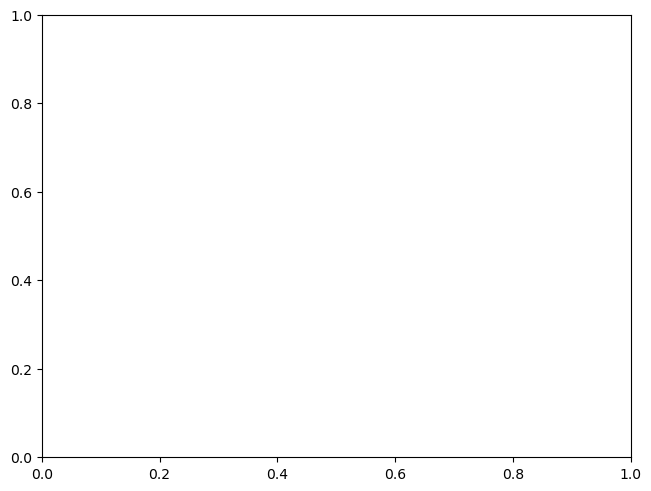

In [18]:
fig, ax = plt.subplots(layout='constrained')

plt.plot(filteredhobo, mandf.loc[:,"SPC bottom before"], 'x', color = "dodgerblue")

plt.show()

In [ ]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
mandf["Date"] = pd.to_datetime(mandf["Date"])

hobodate = hobodf["Date-Time (CST/CDT)"]
slicedhobodate = hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(slicedhobodate, filteredhobo, s = 0.3, color="blue", label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2026-02"), pd.to_datetime("2026-06")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
#finding the calibration factor
# hobodf = pd.read_csv("P1_All_6.16.csv")
# hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
# mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
# mandf["Date"] = pd.to_datetime(mandf["Date"])

fig, ax = plt.subplots(layout='constrained')
ax.scatter(filteredhobo, mandf.loc[:,"SPC bottom before"], s = 0.3, color="green", label = "manual (bb) versus continuous")
# ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2026-02"), pd.to_datetime("2026-06")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
mandf["Date"] = pd.to_datetime(mandf["Date"])

hobodate = hobodf["Date-Time (CST/CDT)"]
hoboSPC = hobodf["Specific Conductivity (W-CT 22414702), µS/cm"]

fig, ax = plt.subplots(layout='constrained')
ax.plot(hobodate, hoboSPC, color="blue", label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")

#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])

hobodate = hobodf["Date-Time (CST/CDT)"]
hoboSPC = hobodf["Specific Conductivity (W-CT 22414702), µS/cm"]

fig, ax = plt.subplots(layout='constrained')
ax.plot(hobodate, hoboSPC, color="blue", label = "HOBO continuous temperature")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")

#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')